# VADER Sentiment Analysis with Naive Bayes Models

In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import ComplementNB, MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

nltk.download('vader_lexicon')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def classify_sentiment(text):
    if not isinstance(text, str):
        text = ""
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return words

def train_evaluate_model(name, model, X, y):
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    
    print(f"\n✅ {name} Model Accuracy (on training data): {accuracy * 100:.2f}%")
    print("------------------------------------------------")
    print("Confusion Matrix:\n", pd.DataFrame(confusion_matrix(y, y_pred)))
    print("------------------------------------------------")
    print("Classification Report:\n", classification_report(y, y_pred))
    
    return model, y_pred

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def generate_wordcloud(words, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()


# Load and classify sentiment

In [3]:
train_df = pd.read_csv('train_dataset.csv')
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
train_df.to_csv('train_dataset_sentiment_VADER.csv', index=False)

sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)

print("Train Sentiment Distribution:\n", train_df['Sentiment'].value_counts())


Train Sentiment Distribution:
 Sentiment
Neutral     2985
Positive    2868
Negative    1294
Name: count, dtype: int64


# TF-IDF Feature Extraction + Naïve Bayes Classification with GridSearch Hyperparameter Optimization

In [4]:

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Drop rows with missing sentiment label just in case
train_df.dropna(subset=['Sentiment_Label'], inplace=True)
train_df['Sentiment_Label'] = train_df['Sentiment_Label'].astype(int)

# Prepare data
X = train_df['Final_Comment']
y = train_df['Sentiment_Label']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', ComplementNB())
])

# Grid search params
param_grid = {
    'tfidf__max_df': [0.8, 1.0],
    'tfidf__min_df': [1, 5],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.1, 0.5, 1.0]
}

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

# Output best params and score
print("Best Parameters:", grid.best_params_)
print("Validation F1 Score:", grid.best_score_)

# Evaluate on test set
y_pred = grid.predict(X_val)
print(classification_report(y_val, y_pred))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'nb__alpha': 1.0, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Validation F1 Score: 0.7757037769264354
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       253
           1       0.86      0.71      0.77       602
           2       0.78      0.90      0.83       575

    accuracy                           0.79      1430
   macro avg       0.78      0.78      0.78      1430
weighted avg       0.80      0.79      0.79      1430



# TF-IDF Vectorization

In [5]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(train_df['Final_Comment'])
y = train_df['Sentiment_Label']

# Also save raw text and labels for training the pipeline
X_train = train_df['Final_Comment']
y_train = y

# WordCloud

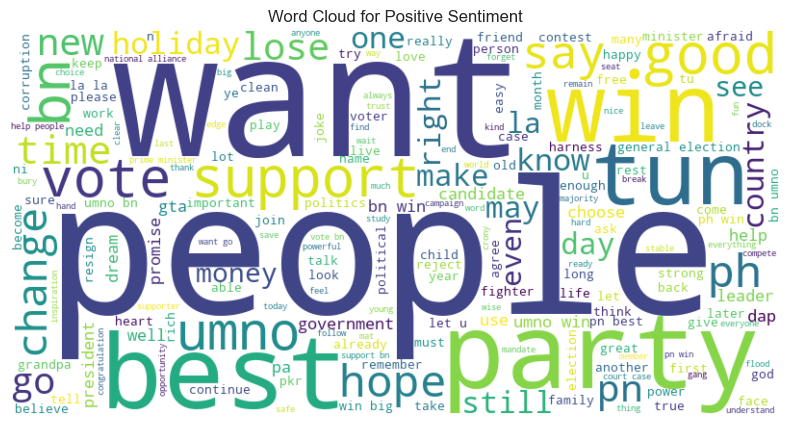

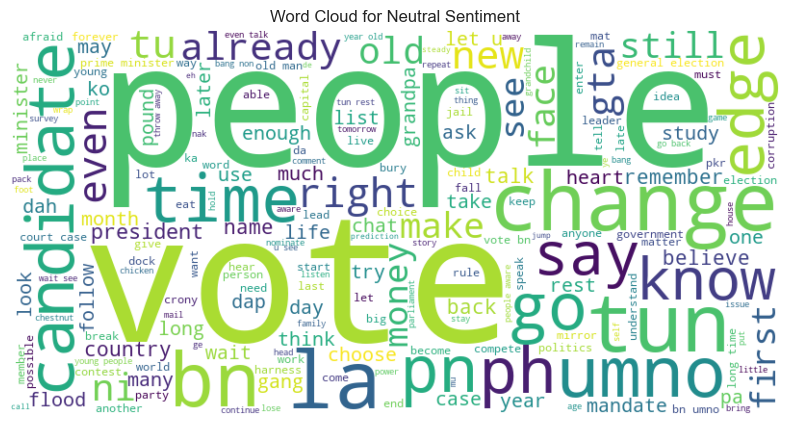

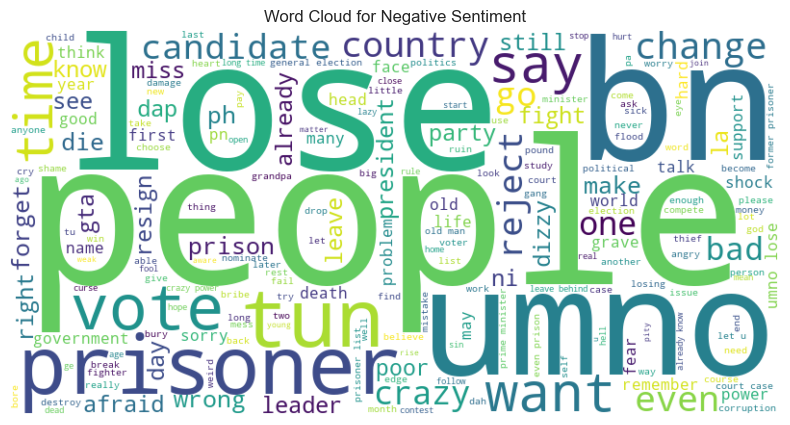

In [6]:

for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    generate_wordcloud(words, f"Word Cloud for {sentiment} Sentiment")


 # Bag of Words Example

In [7]:
positive_word = Counter(train_df[train_df['Sentiment'] == 'Positive']['Final_Comment'].apply(preprocess_text).sum()).most_common(1)[0][0]
negative_word = Counter(train_df[train_df['Sentiment'] == 'Negative']['Final_Comment'].apply(preprocess_text).sum()).most_common(1)[0][0]
vectorizer_bow = CountVectorizer(vocabulary=[positive_word, negative_word])
X_bow = vectorizer_bow.fit_transform(train_df['Final_Comment'])
pd.DataFrame(X_bow.toarray(), columns=vectorizer_bow.get_feature_names_out()).head()


,win,people
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0


# Train and Evaluate ComplementNB Pipeline Model


✅ ComplementNB Model Accuracy (on training data): 91.59%
------------------------------------------------
Confusion Matrix:
       0     1     2
0  1181    52    61
1    69  2634   282
2    36   101  2731
------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92      1294
           1       0.95      0.88      0.91      2985
           2       0.89      0.95      0.92      2868

    accuracy                           0.92      7147
   macro avg       0.92      0.92      0.92      7147
weighted avg       0.92      0.92      0.92      7147



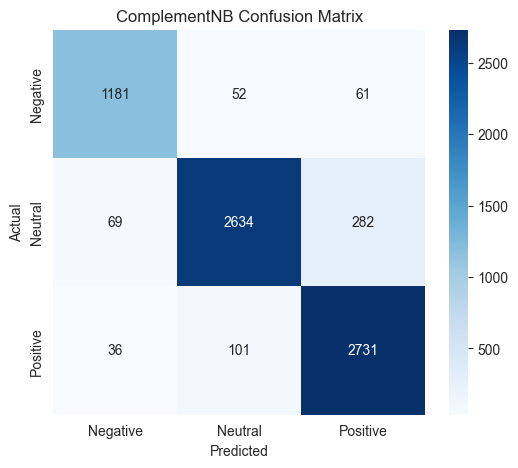

In [8]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(TfidfVectorizer(max_features=5000), ComplementNB())
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"\n✅ ComplementNB Model Accuracy (on training data): {accuracy * 100:.2f}%")
print("------------------------------------------------")
print("Confusion Matrix:\n", pd.DataFrame(confusion_matrix(y_train, y_pred)))
print("------------------------------------------------")
print("Classification Report:\n", classification_report(y_train, y_pred))

# Plot
plot_confusion_matrix(y_train, y_pred, "ComplementNB Confusion Matrix")

# Feature Importance (ComplementNB)

C:\Users\amirb\AppData\Local\Temp\ipykernel_22800\638895383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')


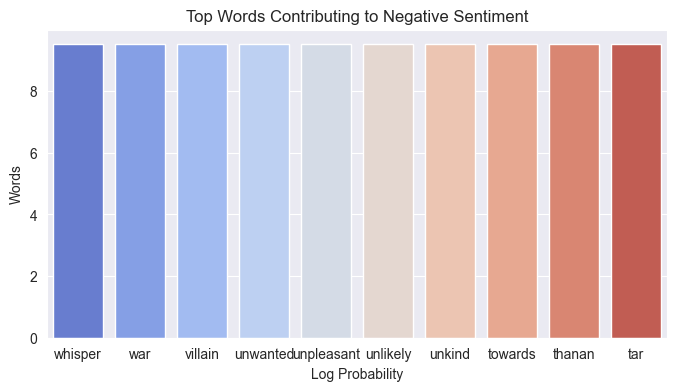

C:\Users\amirb\AppData\Local\Temp\ipykernel_22800\638895383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')


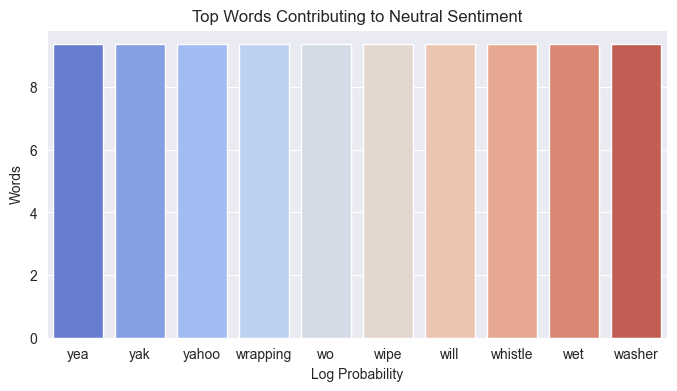

C:\Users\amirb\AppData\Local\Temp\ipykernel_22800\638895383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')


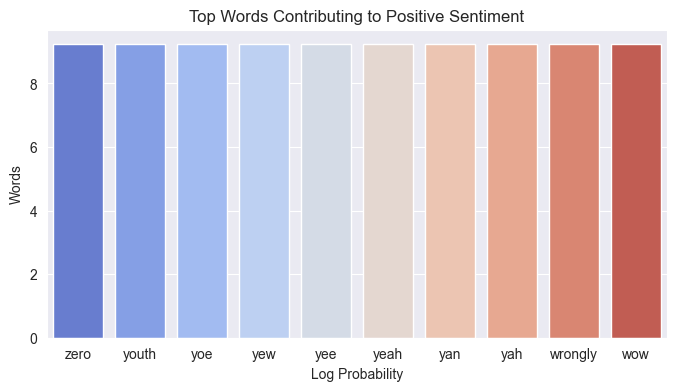

In [9]:
feature_names = model.named_steps['tfidfvectorizer'].get_feature_names_out()
feature_log_probs = model.named_steps['complementnb'].feature_log_prob_

for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    top_features = sorted(zip(feature_log_probs[i], feature_names), reverse=True)[:10]
    words, scores = zip(*top_features)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
    plt.title(f"Top Words Contributing to {label} Sentiment")
    plt.xlabel("Log Probability")
    plt.ylabel("Words")
    plt.show()

# Plot Sentiment Distribution

C:\Users\amirb\AppData\Local\Temp\ipykernel_22800\462083649.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


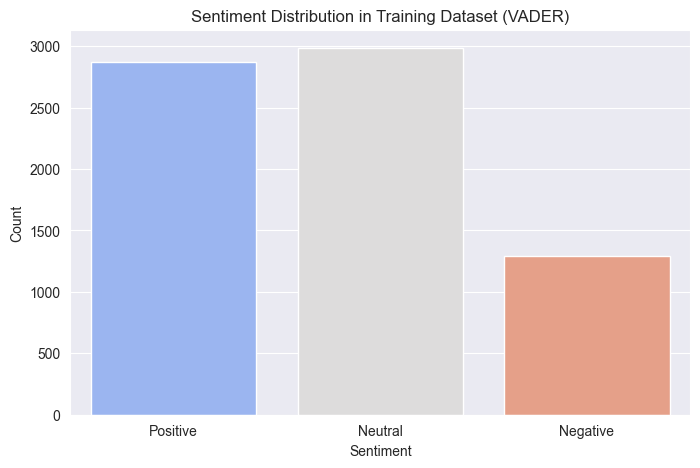

In [10]:
plot_sentiment_distribution(train_df, "Sentiment Distribution in Training Dataset (VADER)")

# Export model and vectorizer

In [11]:
joblib.dump(model, 'complementnb_model_vader.joblib')
print("✅ VADER-based pipeline model saved.")

✅ VADER-based pipeline model saved.
